# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore the characteristics of the retail lending portfolio and understand the relationship between borrower attributes and default behaviour. The insights gained from this analysis will support feature engineering, variable selection, and Probability of Default (PD) model development under the IFRS 9 Expected Credit Loss (ECL) framework.

## Analysis Overview

This notebook covers the following analyses:

- **Portfolio Overview and Default Behaviour:** Examine the overall composition of the lending portfolio across key borrower and loan characteristics.
- **Numerical Variable Analysis:** Assess how key financial variables differ between defaulted and non-defaulted borrowers.
- **Variable Relationships:** Explore relationships between important numerical variables to identify potential patterns and interactions.

## Deliverables

The output of this notebook:

**Business Interpretations:** 

The exploratory analysis identifies several characteristics associated with borrower credit risk. The portfolio is primarily composed of performing loans with a low overall default rate (0.73%), resulting in a highly imbalanced classification problem that should be considered during model development.

Among the categorical variables, credit grade and sub-grade demonstrate the strongest relationship with default behaviour, with default rates increasing consistently as credit quality deteriorates. This indicates that the lender's internal risk grading system effectively differentiates borrower risk and provides strong evidence that borrower credit quality is one of the most important drivers of default. In addition, although default rates increase substantially in lower credit grades, approximately 80% of the portfolio is concentrated in Grades A–C. This suggests that portfolio risk is mitigated through a conservative credit allocation strategy that limits exposure to higher-risk borrowers.

Loan purpose exhibits noticeable variation in observed default rates across borrower segments, while homeownership, loan term, and income verification show more modest differences. Several categories contain relatively few observations, therefore the corresponding default rates should be interpreted cautiously due to limited statistical reliability.

The numerical analysis shows that individual financial variables alone provide limited separation between defaulted and non-defaulted borrowers. Variables such as annual income, debt-to-income ratio, total credit utilized, and credit age exhibit substantial overlap between the two groups. This suggests that default risk is unlikely to be explained by any single borrower characteristic and instead arises from the interaction of multiple financial factors.

Further analysis indicates that lower credit grades are generally associated with higher debt-to-income ratios, larger loan amounts, and higher monthly installment obligations. These patterns suggest that weaker credit quality is accompanied by greater borrower leverage and repayment burden, highlighting the importance of incorporating multiple borrower and loan characteristics when predicting default risk.

Overall, the exploratory analysis supports the development of a predictive model that combines multiple borrower, loan, and credit characteristics.



> **Note:** Data quality assessments—including missing value analysis, outlier analysis, correlation analysis, and target leakage review—were completed in a separate Data Quality Assessment notebook and are not repeated here.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import seaborn as sns

plt.style.use("ggplot")

sns.set_theme(
    style="whitegrid",
    palette="Blues"
)

In [44]:
RAW_DATA = "../data/loan_raw.csv"

In [45]:
df = pd.read_csv(RAW_DATA)

In [47]:
default_status = [
    "Charged Off",
    "Late (31-120 days)"
]

df["default"] = df["loan_status"].isin(default_status).astype(int)

In [48]:
default_variables = [
    "grade",
    "sub_grade",
    "loan_purpose",
    "homeownership",
    "emp_length",
    "verified_income",
    "state",
    "term"
]

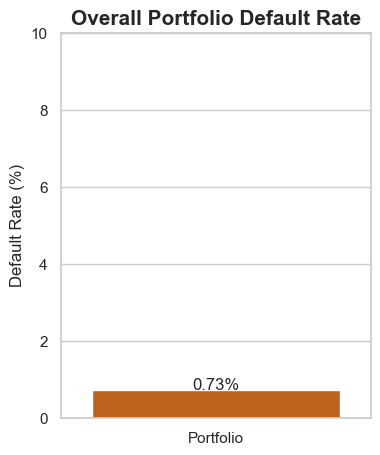

In [51]:
overall_default = df["default"].mean() * 100

plt.figure(figsize=(4,5))

ax = sns.barplot(
    x=["Portfolio"],
    y=[overall_default],
    color="#D95F02"
)

ax.annotate(
    f"{overall_default:.2f}%",
    (0, overall_default),
    ha="center",
    fontsize=12
)

plt.ylabel("Default Rate (%)")
plt.title(
    "Overall Portfolio Default Rate",
    fontsize=15,
    weight="bold"
)

plt.ylim(0, max(overall_default*1.2, 10))

plt.show()

In [ ]:
def plot_distribution_default_rate_horizontal(
    df,
    variable,
    top_n=None,
    order=None,
    figsize=(10,8)
):

    distribution = (
        df[variable]
        .value_counts(dropna=False, normalize=True)
        .mul(100)
    )

    default_rate = (
        df.groupby(variable)["default"]
          .mean()
          .mul(100)
    )

    if order is not None:
        distribution = distribution.reindex(order).fillna(0)
        default_rate = default_rate.reindex(order)

    else:
        distribution = distribution.sort_values(ascending=True)
        default_rate = default_rate.reindex(distribution.index)

    if top_n is not None:
        distribution = distribution.tail(top_n)
        default_rate = default_rate.loc[distribution.index]

    fig, ax1 = plt.subplots(figsize=figsize)

    bars = ax1.barh(
        distribution.index.astype(str),
        distribution.values,
        color="#2C7FB8",
        alpha=0.8,
        label="Portfolio Distribution"
    )

    ax1.set_xlabel("Portfolio Distribution (%)", color="#2C7FB8")
    ax1.tick_params(axis="x", labelcolor="#2C7FB8")

    for bar in bars:
        ax1.text(
            bar.get_width() + 0.2,
            bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1f}%",
            va="center",
            fontsize=9
        )

    ax2 = ax1.twiny()

    ax2.plot(
        default_rate.values,
        distribution.index.astype(str),
        color="#D95F02",
        marker="o",
        linewidth=2,
        markersize=6,
        label="Default Rate"
    )

    ax2.set_xlabel("Default Rate (%)", color="#D95F02")
    ax2.tick_params(axis="x", labelcolor="#D95F02")

    for x, y in zip(default_rate.values, distribution.index.astype(str)):
        ax2.text(
            x + 0.05,
            y,
            f"{x:.1f}%",
            va="center",
            fontsize=9,
            color="#D95F02"
        )

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        handles1 + handles2,
        labels1 + labels2,
        loc="lower right"
    )

    plt.title(
        f"{variable.replace('_',' ').title()}: Portfolio Distribution vs Default Rate",
        fontsize=15,
        weight="bold"
    )

    plt.tight_layout()
    plt.show()

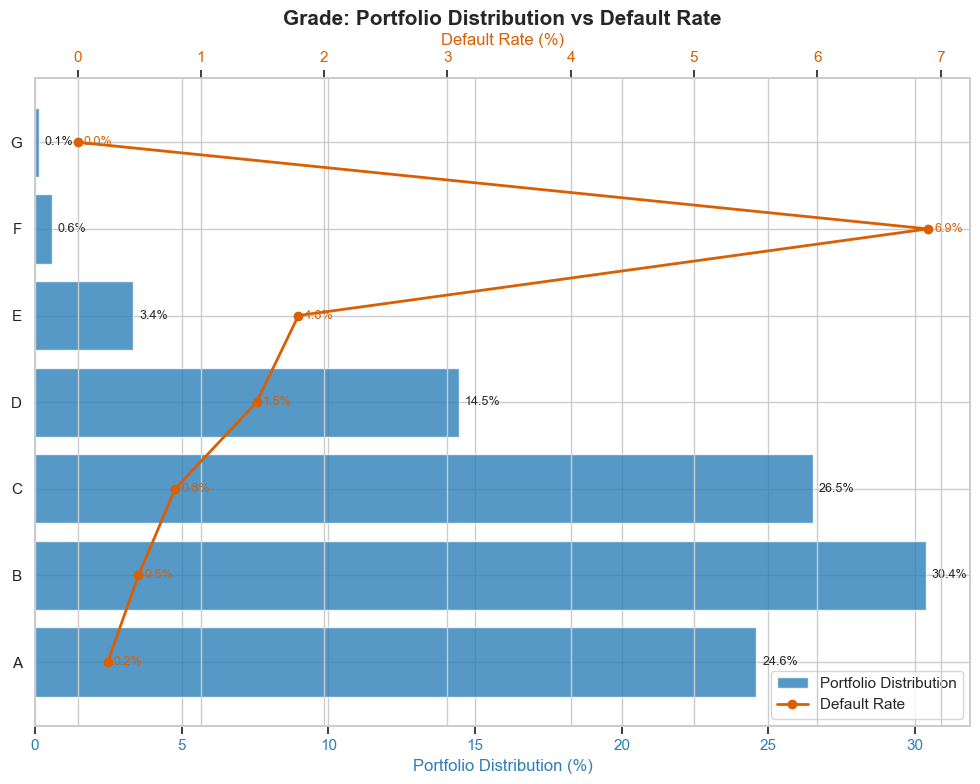

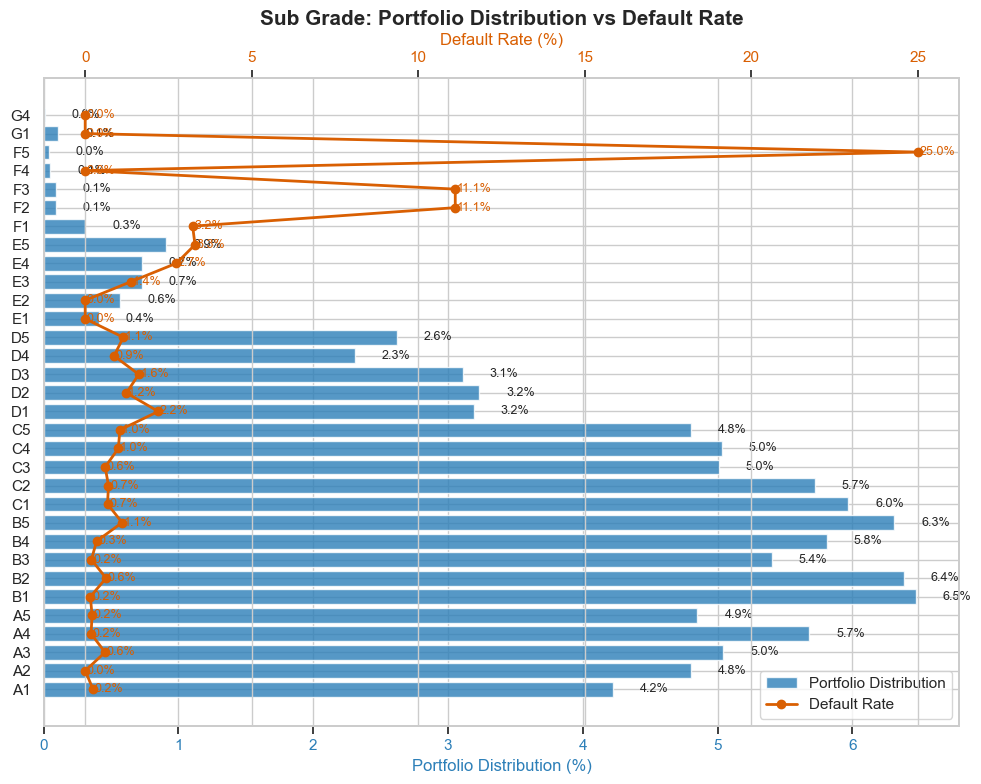

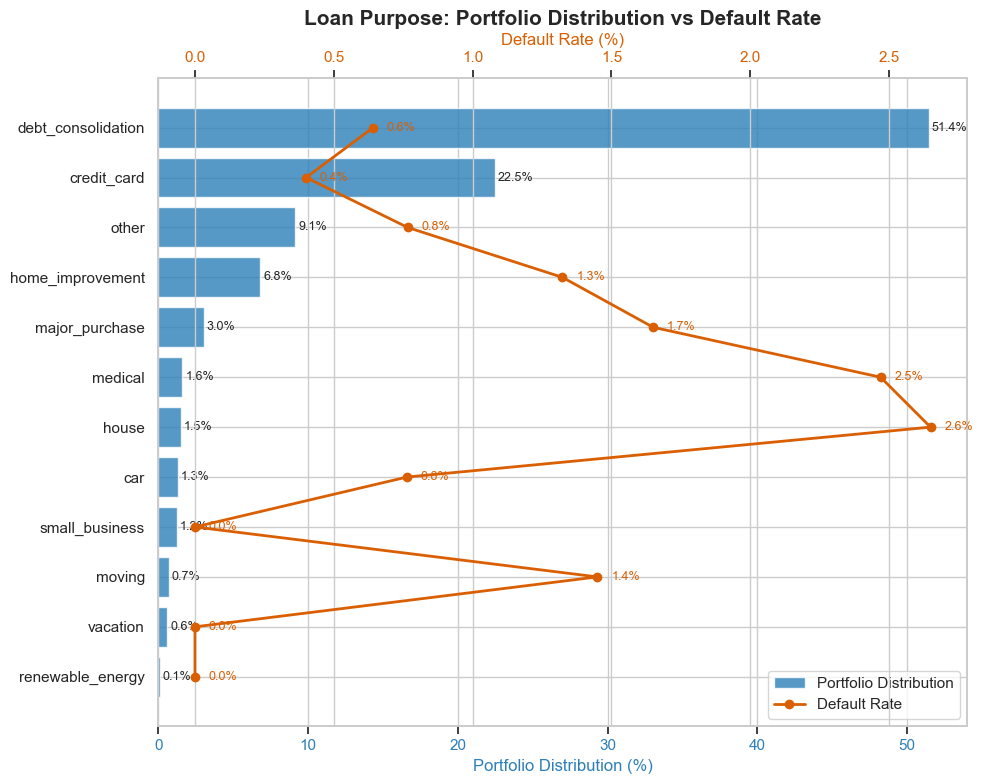

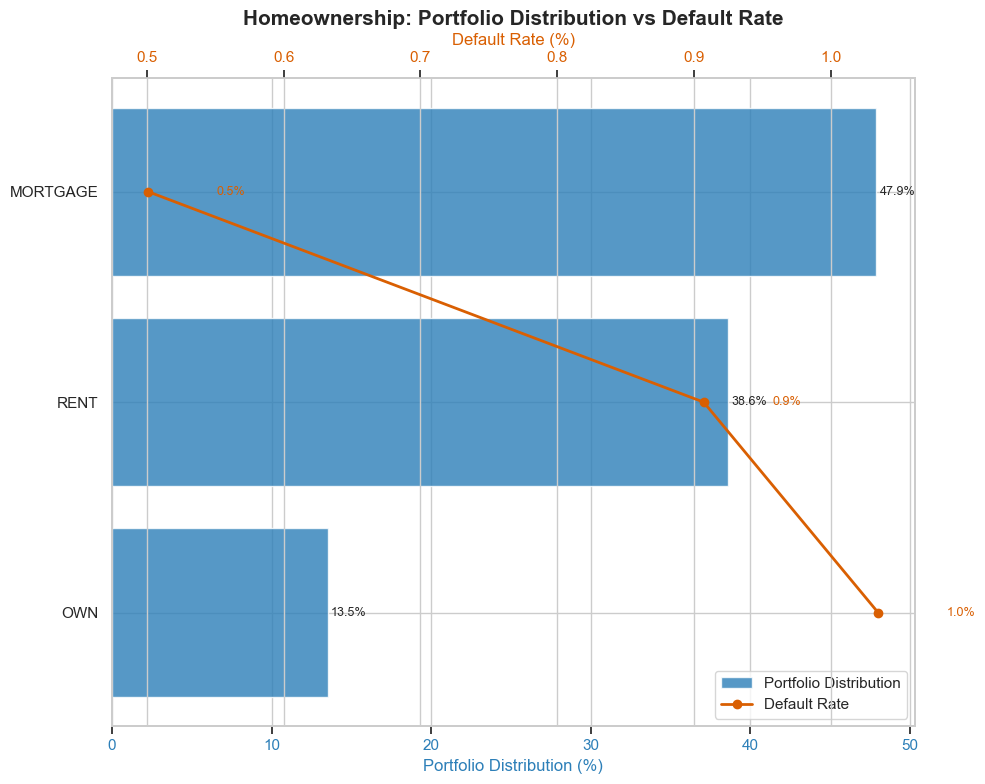

posx and posy should be finite values
posx and posy should be finite values


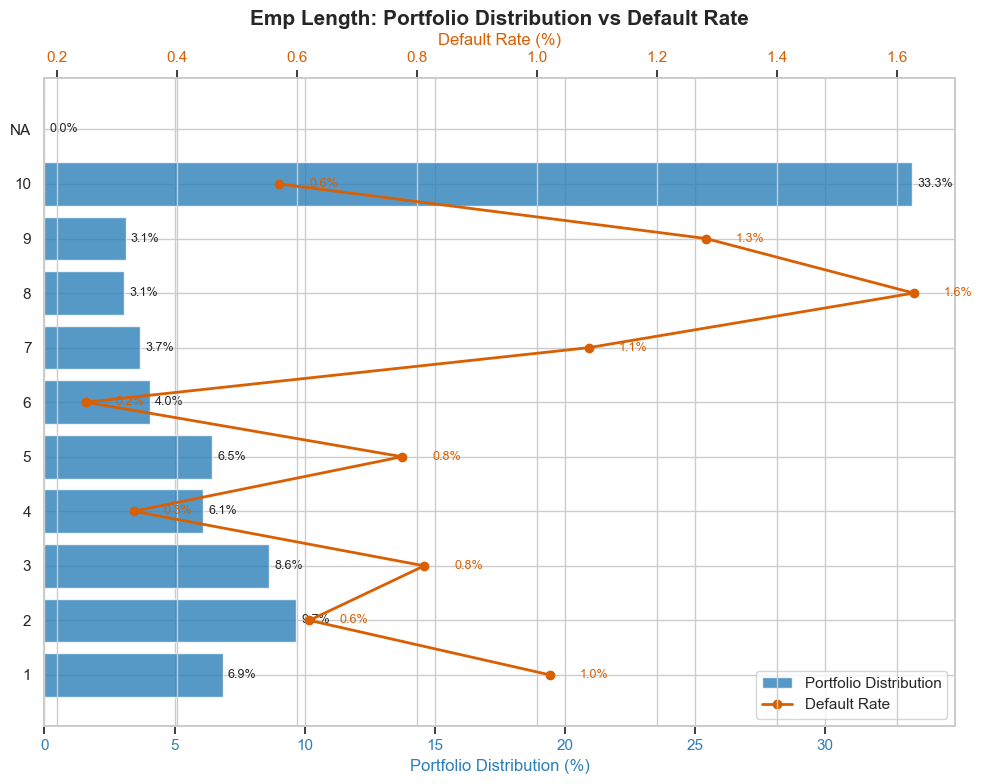

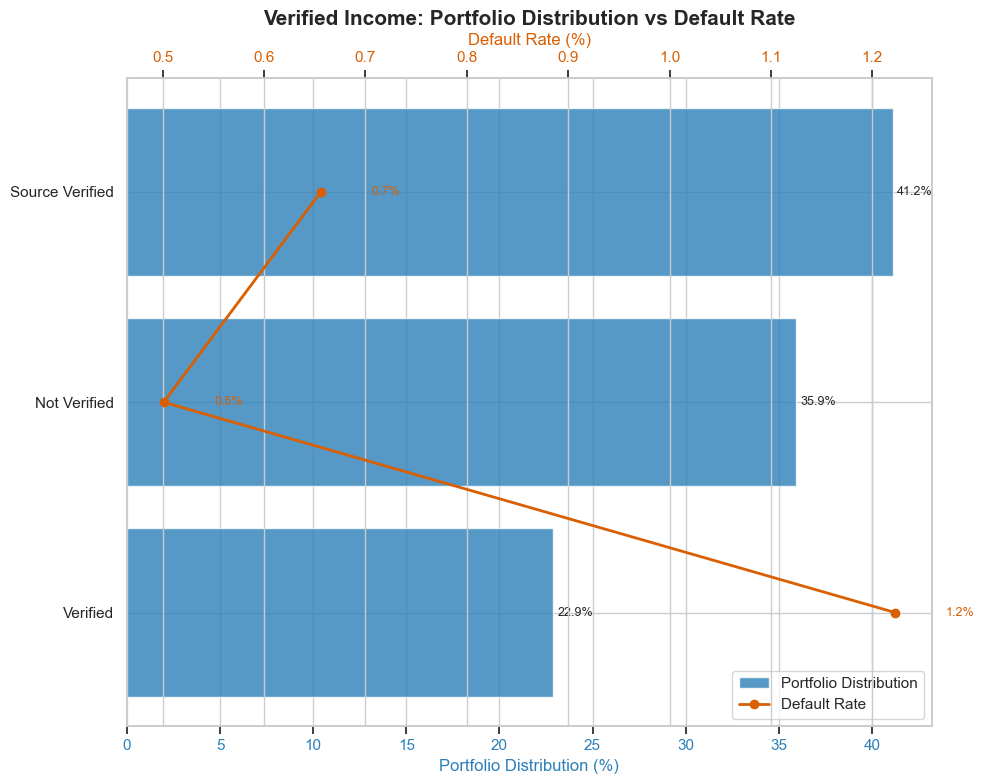

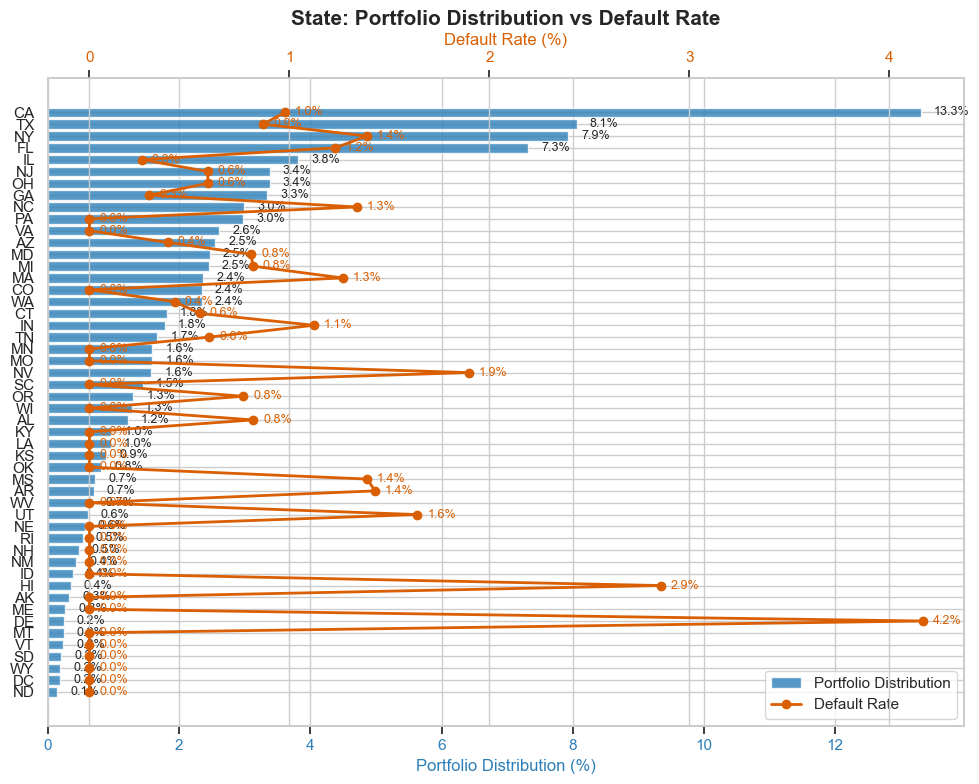

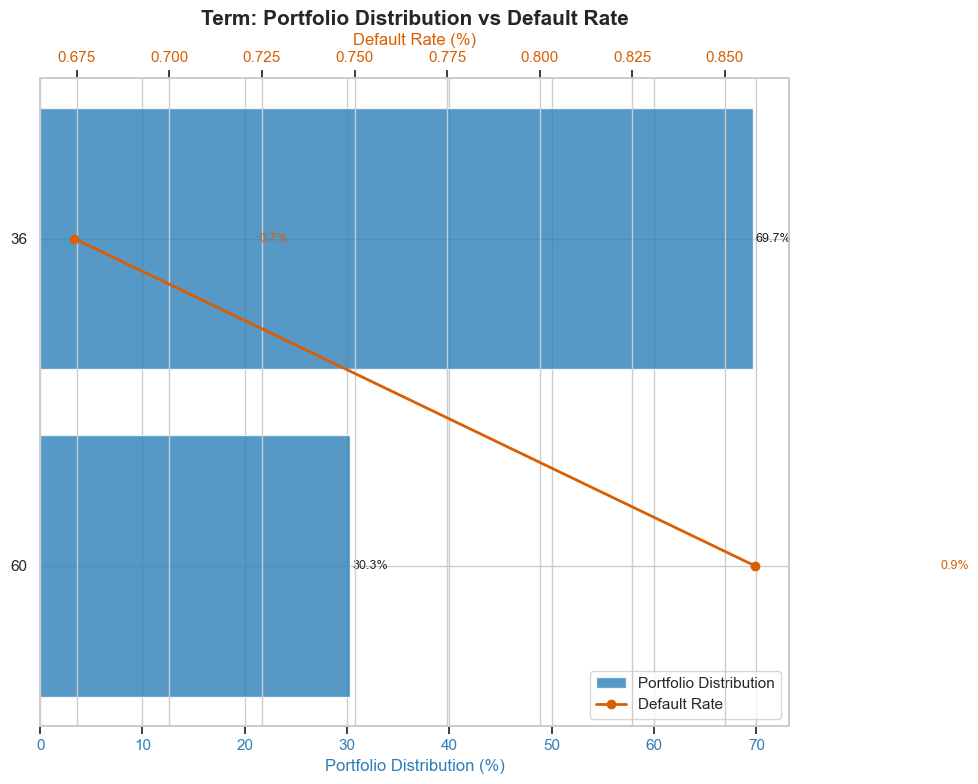

In [50]:
for var in default_variables:
    
    if var == "grade":
        plot_distribution_default_rate_horizontal(
            df,
            variable=var,
            order=["A", "B", "C", "D", "E", "F", "G"]
        )

    elif var == "sub_grade":
        plot_distribution_default_rate_horizontal(
            df,
            variable=var,
            order=["A1","A2","A3","A4","A5","B1","B2","B3","B4","B5","C1","C2","C3","C4","C5","D1","D2","D3","D4","D5","E1","E2","E3","E4","E5","F1","F2","F3","F4","F5","G1","G4"]
        )
    elif var == "emp_length":
        plot_distribution_default_rate_horizontal(
            df,
            variable=var,
            order=[1,2,3,4,5,6,7,8,9,10,"NA"]
        )
        
    else:
        plot_distribution_default_rate_horizontal(
            df,
            variable=var
        )

In [52]:
numeric_variables = [
    "annual_income",
    "debt_to_income",
    "total_credit_utilized",
    "total_credit_limit",
    "loan_amount",
    "installment",
    "num_open_cc_accounts",
    "credit_age"      
]

In [53]:
df["earliest_credit_line"] = pd.to_datetime(
    df["earliest_credit_line"]
)

df["issue_month"] = pd.to_datetime(
    df["issue_month"],
    format="%b-%y"
)

df["credit_age"] = (
    (df["issue_month"] - df["earliest_credit_line"]).dt.days / 365.25
)

In [54]:
def plot_boxplot_default(
    df,
    variable,
    figsize=(8,5)
):

    plt.figure(figsize=figsize)

    sns.boxplot(
        data=df,
        x="default",
        y=variable,
        palette=["#4C72B0", "#DD8452"],
        showfliers=False
    )

    plt.xticks(
        [0,1],
        ["Non-default","Default"]
    )

    plt.xlabel("")
    plt.ylabel(variable.replace("_"," ").title())

    plt.title(
        f"{variable.replace('_',' ').title()} by Default Status",
        fontsize=15,
        weight="bold"
    )

    plt.tight_layout()

    plt.show()

In [55]:
def numerical_summary(df, variable):

    summary = (
        df.groupby("default")[variable]
          .agg(
              Count="count",
              Mean="mean",
              Median="median",
              Std="std",
              Min="min",
              Max="max"
          )
          .round(2)
    )

    display(summary)

ANNUAL_INCOME


,Count,Mean,Median,Std,Min,Max
default,,,,,,
0,9927,79223.74,65000.0,64846.22,0.0,2300000.0
1,73,79005.09,70000.0,47426.10,14400.0,258000.0


C:\Users\Lindsey Wang\AppData\Local\Temp\ipykernel_11560\3053945326.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


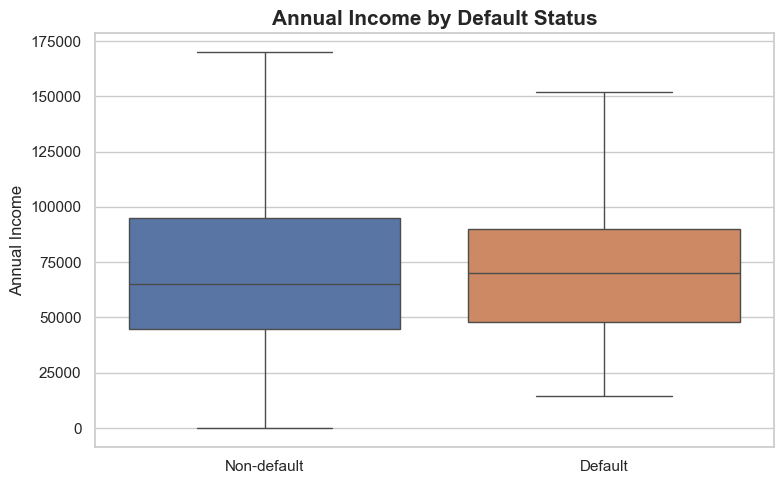

DEBT_TO_INCOME


,Count,Mean,Median,Std,Min,Max
default,,,,,,
0,9903,19.33,17.57,15.03,0.0,469.09
1,73,16.27,15.95,10.70,0.0,36.24


C:\Users\Lindsey Wang\AppData\Local\Temp\ipykernel_11560\3053945326.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


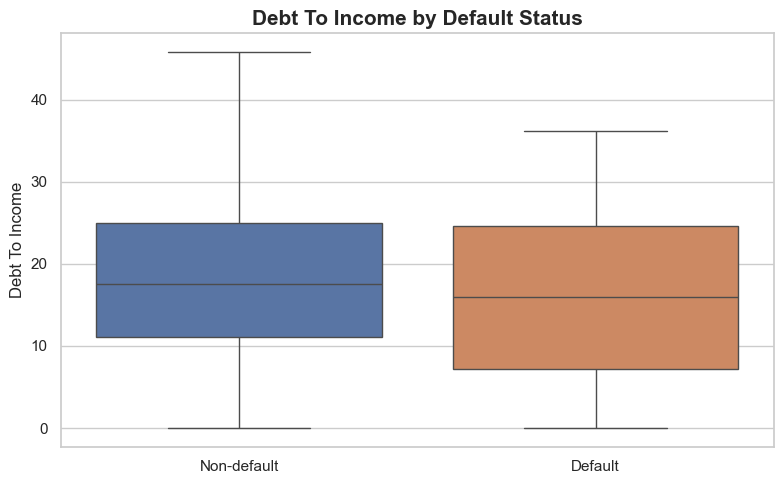

TOTAL_CREDIT_UTILIZED


,Count,Mean,Median,Std,Min,Max
default,,,,,,
0,9927,51076.98,36933.0,53643.99,0,942456
1,73,47252.81,35107.0,52866.09,0,303858


C:\Users\Lindsey Wang\AppData\Local\Temp\ipykernel_11560\3053945326.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


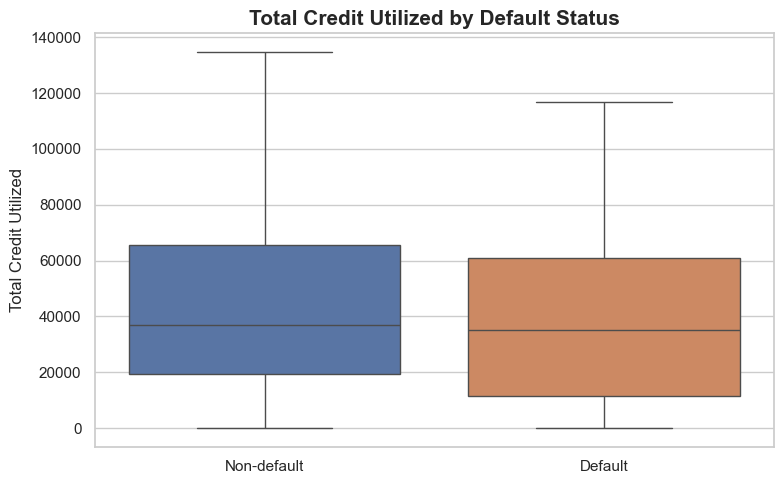

TOTAL_CREDIT_LIMIT


,Count,Mean,Median,Std,Min,Max
default,,,,,,
0,9927,183805.63,114956.0,187761.40,0,3386034
1,73,156491.08,88878.0,168178.25,1700,767814


C:\Users\Lindsey Wang\AppData\Local\Temp\ipykernel_11560\3053945326.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


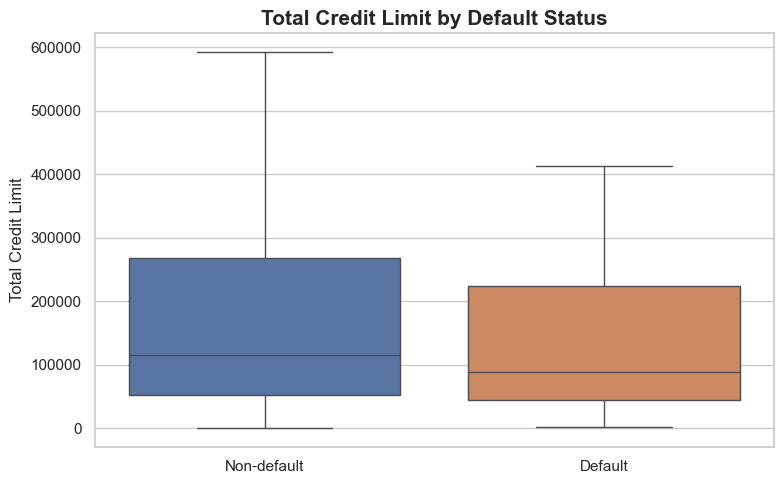

LOAN_AMOUNT


,Count,Mean,Median,Std,Min,Max
default,,,,,,
0,9927,16348.07,14500.0,10296.89,1000,40000
1,73,18245.55,15000.0,10879.37,3000,40000


C:\Users\Lindsey Wang\AppData\Local\Temp\ipykernel_11560\3053945326.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


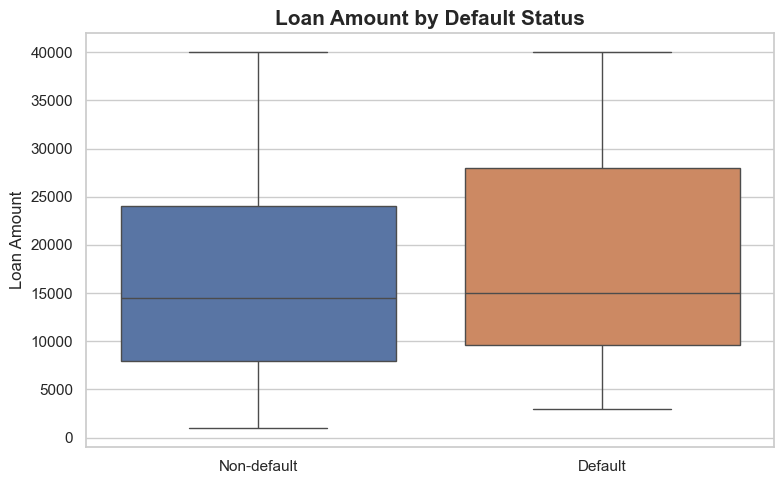

INSTALLMENT


,Count,Mean,Median,Std,Min,Max
default,,,,,,
0,9927,475.57,398.08,294.40,30.75,1566.59
1,73,562.55,464.94,342.96,93.96,1479.87


C:\Users\Lindsey Wang\AppData\Local\Temp\ipykernel_11560\3053945326.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


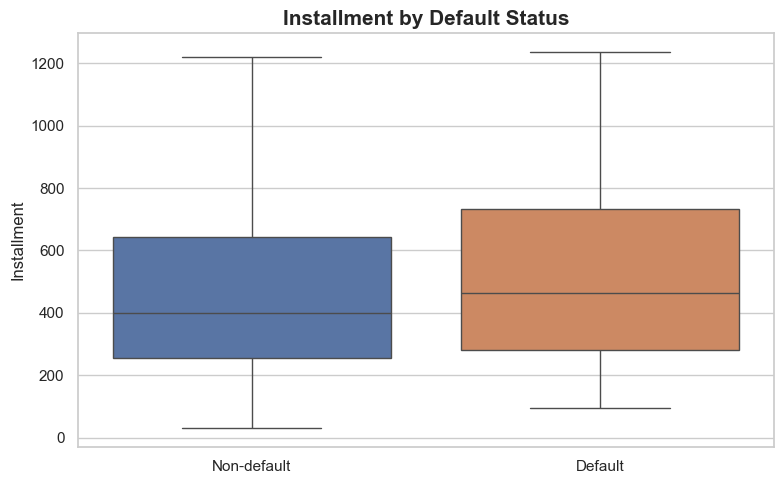

NUM_OPEN_CC_ACCOUNTS


,Count,Mean,Median,Std,Min,Max
default,,,,,,
0,9927,8.11,7.0,4.91,0,46
1,73,6.66,6.0,4.49,1,24


C:\Users\Lindsey Wang\AppData\Local\Temp\ipykernel_11560\3053945326.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


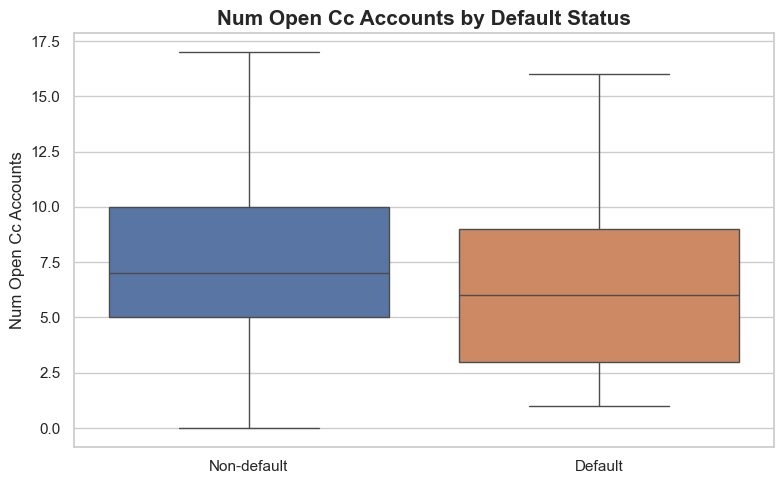

CREDIT_AGE


,Count,Mean,Median,Std,Min,Max
default,,,,,,
0,9927,48.08,48.08,0.07,48.0,48.16
1,73,48.07,48.08,0.07,48.0,48.16


C:\Users\Lindsey Wang\AppData\Local\Temp\ipykernel_11560\3053945326.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


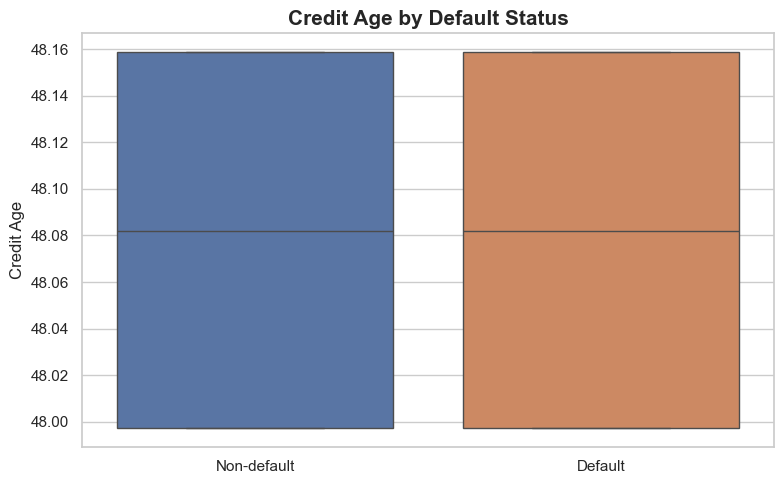

In [56]:
for var in numeric_variables:

    print(var.upper())

    numerical_summary(df, var)

    plot_boxplot_default(df, var)

In [57]:
def plot_scatter_two_panel(
    df,
    x,
    y,
    alpha=0.5,
    s=15,
    figsize=(14,6),
):

    df_nondefault = df[df["default"] == 0]
    df_default = df[df["default"] == 1]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=figsize,
        sharex=True,
        sharey=True
    )
    
    upper_y = df[y].quantile(0.99)

    sns.scatterplot(
        data=df_nondefault,
        x=x,
        y=y,
        color="#2C7FB8",
        alpha=alpha,
        s=s,
        edgecolor=None,
        ax=axes[0]
    )

    axes[0].set_title(
        "Non-default",
        fontsize=14,
        weight="bold",
        color="#2C7FB8"
    )
    
    axes[0].set_xlim(
    0,
    df[x].quantile(0.99)
    )
    
    axes[0].set_ylim(0, upper_y)


    sns.scatterplot(
        data=df_default,
        x=x,
        y=y,
        color="#D95F02",
        alpha=alpha,
        s=s,
        edgecolor=None,
        ax=axes[1]
    )

    axes[1].set_title(
        "Default",
        fontsize=14,
        weight="bold",
        color="#D95F02"
    )
    
    axes[1].set_xlim(
    0,
    df[x].quantile(0.99)
    )
    
    axes[1].set_ylim(0, upper_y)


    for ax in axes:

        # Add comma separator
        ax.xaxis.set_major_formatter(
            StrMethodFormatter("{x:,.0f}")
        )

        ax.yaxis.set_major_formatter(
            StrMethodFormatter("{x:,.0f}")
        )

        ax.set_xlabel(
            x.replace("_"," ").title()
        )

        ax.grid(alpha=0.3)

    axes[0].set_ylabel(
        y.replace("_"," ").title()
    )

    axes[1].set_ylabel("")

    plt.suptitle(
        f"{y.replace('_',' ').title()} vs {x.replace('_',' ').title()}",
        fontsize=16,
        weight="bold"
    )

    plt.tight_layout()

    plt.show()

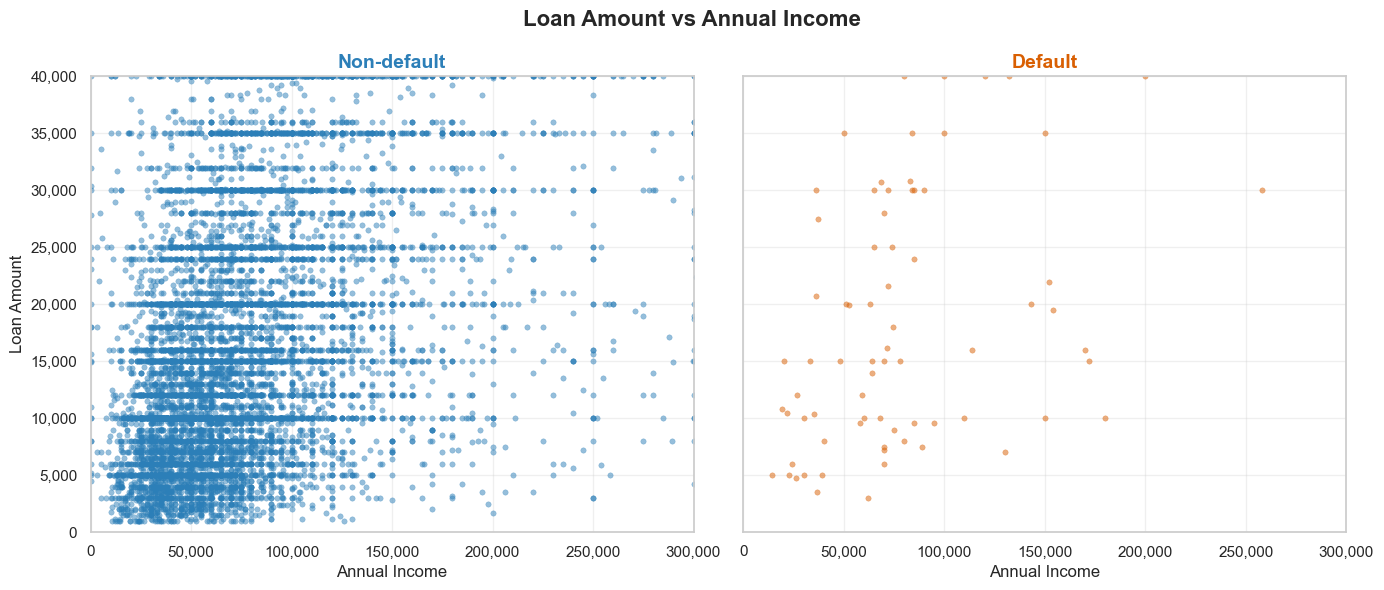

In [58]:
plot_scatter_two_panel(
    df,
    x="annual_income",
    y="loan_amount"
)

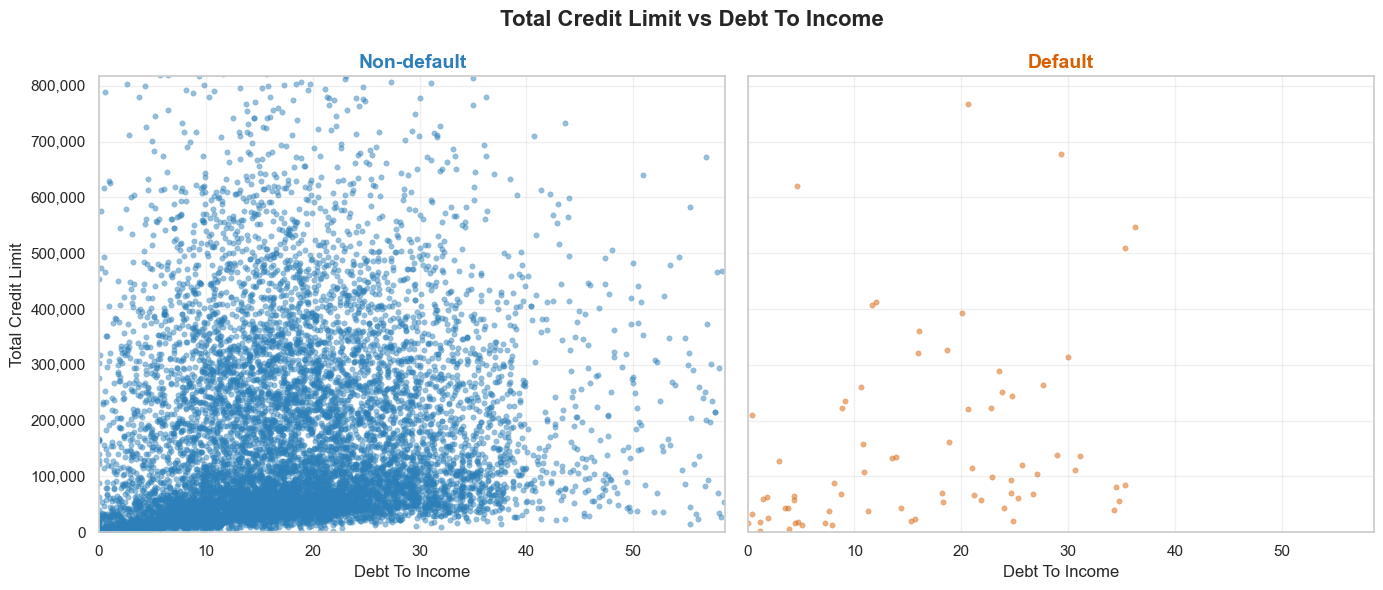

In [59]:
plot_scatter_two_panel(
    df,
    x="debt_to_income",
    y="total_credit_limit"
)

In [60]:
def plot_box_by_category(
    df,
    category,
    numeric,
    order=None,
    figsize=(10,5)
):

    plt.figure(figsize=figsize)

    sns.boxplot(
        data=df,
        x=category,
        y=numeric,
        hue=category,
        order=order,
        legend=False,
        showfliers=False
    )

    plt.title(
        f"{numeric.replace('_',' ').title()} by {category.replace('_',' ').title()}",
        fontsize=15,
        weight="bold"
    )

    plt.xlabel("")
    plt.ylabel(numeric.replace("_"," ").title())

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

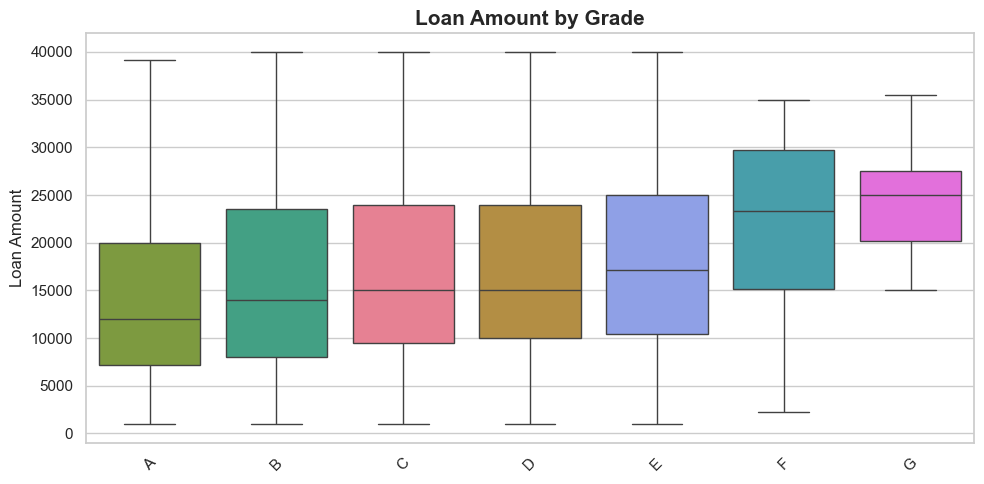

In [61]:
grade_order = ["A","B","C","D","E","F","G"]

plot_box_by_category(
    df,
    category="grade",
    numeric="loan_amount",
    order=grade_order
)

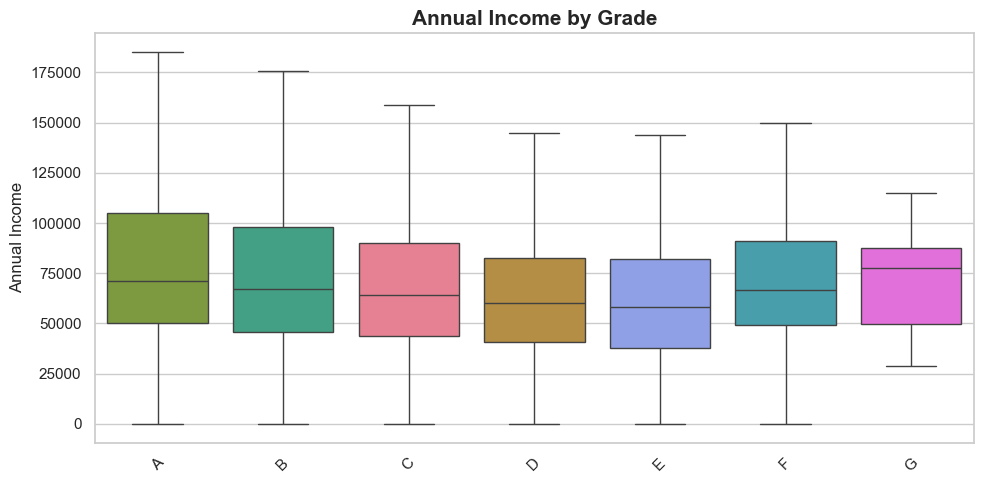

In [62]:
plot_box_by_category(
    df,
    category="grade",
    numeric="annual_income",
    order=grade_order
)

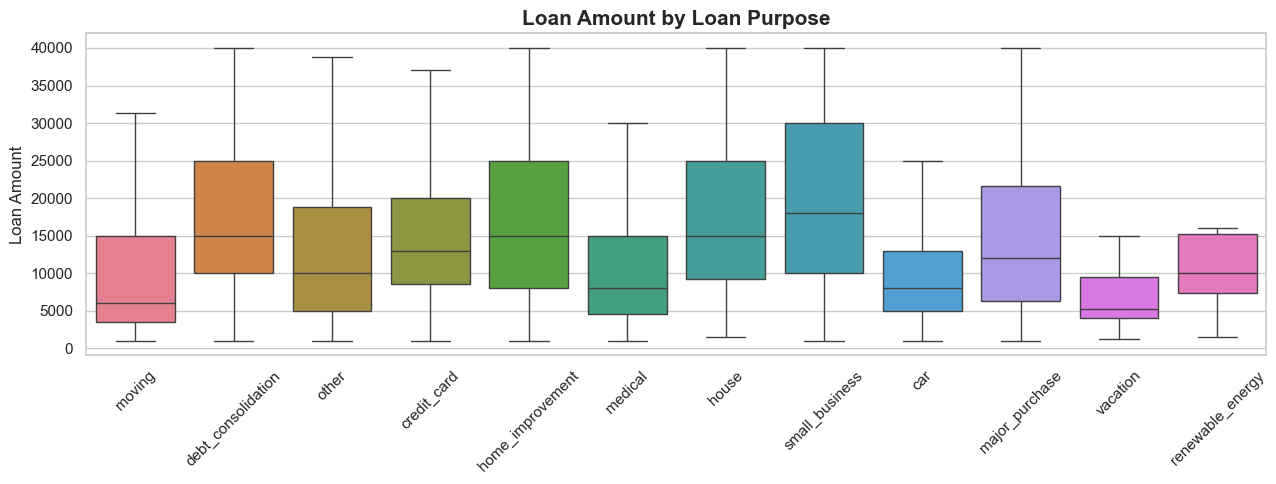

In [63]:
plot_box_by_category(
    df,
    category="loan_purpose",
    numeric="loan_amount",
    figsize=(13,5)
)

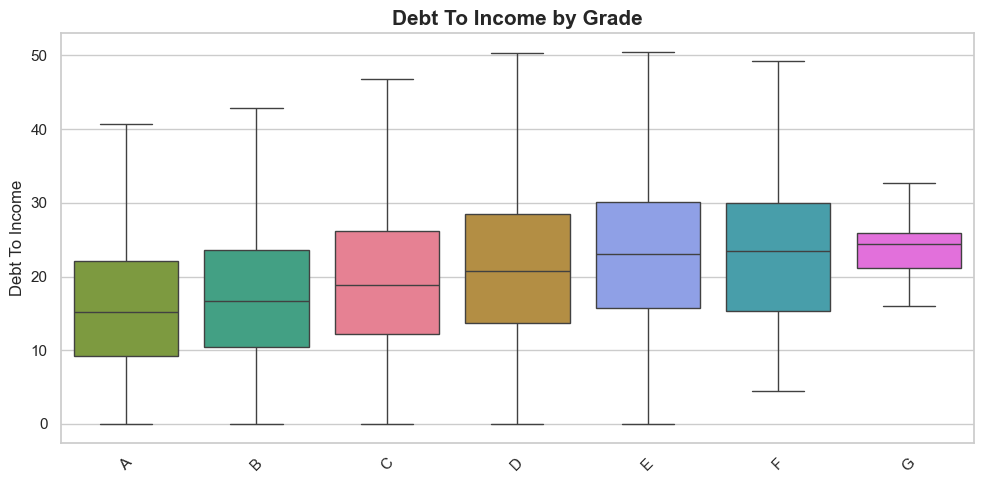

In [64]:
plot_box_by_category(
    df,
    category="grade",
    numeric="debt_to_income",
    order=grade_order
)

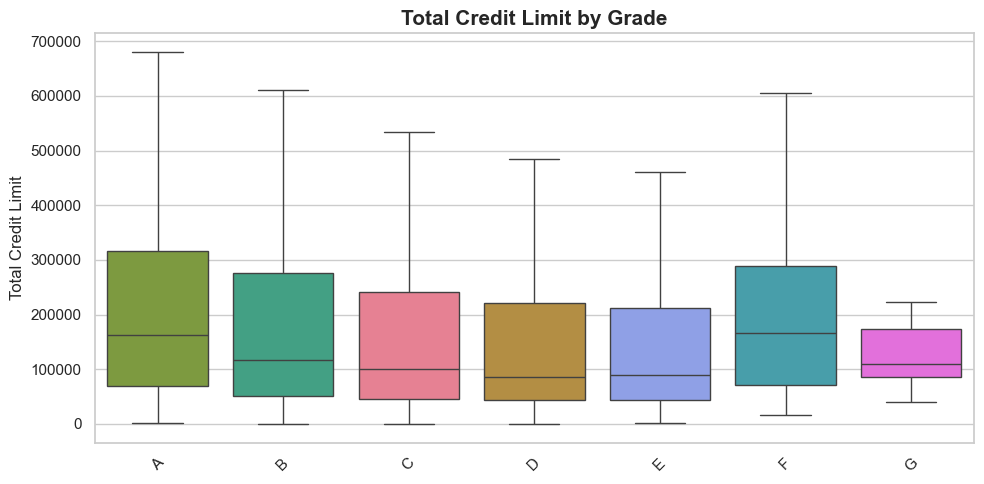

In [65]:
plot_box_by_category(
    df,
    category="grade",
    numeric="total_credit_limit",
    order=grade_order
)

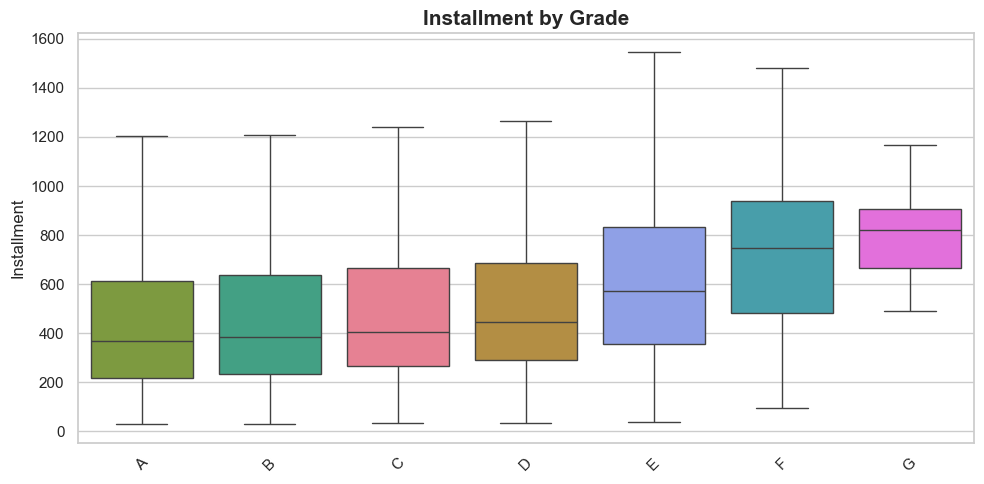

In [66]:
plot_box_by_category(
    df,
    category="grade",
    numeric="installment",
    order=grade_order
)